In [31]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [32]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    health: str

In [33]:
def calculateBmi(state:BMIState) -> BMIState:
    height = state["height"]
    weight = state["weight"]
    bmi = weight / (height * height)
    state["bmi"] = bmi
    return state

In [34]:
def checkHealth(state:BMIState):
    bmi = state["bmi"]
    if bmi < 18:
        state["health"] = "Underweight"
    elif bmi < 25:
        state["health"] = "Normal"
    else:
        state["health"] = "Overweight"
    return state


In [35]:
graph = StateGraph(BMIState)
graph.add_edge(START, "calculate_bmi")
graph.add_node("calculate_bmi", calculateBmi)
graph.add_node("check_health", checkHealth)
graph.add_edge("calculate_bmi", "check_health")
graph.add_edge("calculate_bmi",END)
workflow = graph.compile()


In [47]:
workflow.invoke({"weight":72,"height":1.78})

{'weight': 72, 'height': 1.78, 'bmi': 22.724403484408533, 'health': 'Normal'}

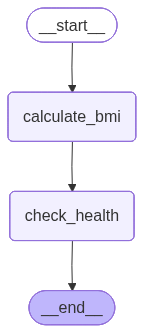

In [37]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())